In [14]:
from pathlib import Path

import numpy as np
import torch
from omegaconf import OmegaConf
from torch.utils.data import DataLoader
from typing import Dict, Tuple

from uncertainty_estimation.geometry.stereo import reproject
from uncertainty_estimation.training.data.semistaticsim import (
    SemiStaticSimStereoDataset,
    stereo_collate,
)
from uncertainty_estimation.training.trainer import _get_depth, _in_bounds

from uncertainty_estimation.matching.orb import ORB as ORBMatcher
from uncertainty_estimation.matching.orb import SIFT 
import matplotlib.pyplot as plt

MAX_SAMPLES      = 2000       # per-config ceiling
TARGET_N_MATCHES = 100_000    # stop early once hit
BATCH_SIZE       = 8
NUM_WORKERS      = 4
DEVICE           = "cpu"
SPLIT            = "train"

ORIENTATIONS = ["horizontal", "vertical"]
BASELINES    = [5, 10, 20, 50, 100]

OUT_DIR = Path("outputs/eval/residuals")




In [15]:
import cv2 as cv

img_path = "/Volumes/T9/datasets/sss/generated_data/semistaticsim/test/0/0/privileged/run_0/images/rgb_first_view/00000.jpg"

def ORB(img_path):
    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    orb = cv.ORB_create()
    #keypoints, descriptors = orb.detectAndCompute(img, None)

    keypoints = orb.detect(img, None)
    keypoints, descriptors = orb.compute(img, keypoints)

    imGray = cv.drawKeypoints(img, keypoints, img, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.figure()
    plt.imshow(imGray)
    plt.show()

    return keypoints, descriptors

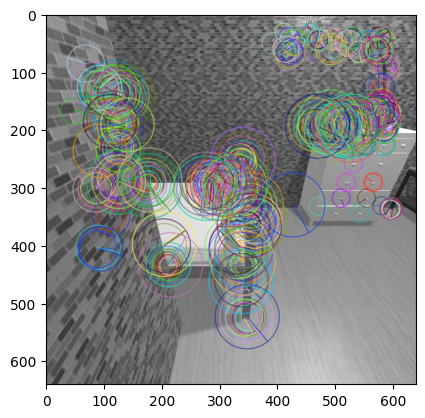

((< cv2.KeyPoint 0x1312caaf0>,
  < cv2.KeyPoint 0x1312cab20>,
  < cv2.KeyPoint 0x1312cab50>,
  < cv2.KeyPoint 0x1312cab80>,
  < cv2.KeyPoint 0x1312cabb0>,
  < cv2.KeyPoint 0x1312cabe0>,
  < cv2.KeyPoint 0x1312cac10>,
  < cv2.KeyPoint 0x1312cac40>,
  < cv2.KeyPoint 0x1312cac70>,
  < cv2.KeyPoint 0x1312caca0>,
  < cv2.KeyPoint 0x1312cacd0>,
  < cv2.KeyPoint 0x1312cad00>,
  < cv2.KeyPoint 0x1312cad30>,
  < cv2.KeyPoint 0x1312cad60>,
  < cv2.KeyPoint 0x1312cad90>,
  < cv2.KeyPoint 0x1312cadc0>,
  < cv2.KeyPoint 0x1312cadf0>,
  < cv2.KeyPoint 0x1312cae20>,
  < cv2.KeyPoint 0x1312cae50>,
  < cv2.KeyPoint 0x1312cae80>,
  < cv2.KeyPoint 0x1312caeb0>,
  < cv2.KeyPoint 0x1312caee0>,
  < cv2.KeyPoint 0x1312caf10>,
  < cv2.KeyPoint 0x1312caf40>,
  < cv2.KeyPoint 0x1312caf70>,
  < cv2.KeyPoint 0x1312cafa0>,
  < cv2.KeyPoint 0x1312cafd0>,
  < cv2.KeyPoint 0x1312cb000>,
  < cv2.KeyPoint 0x1312cb030>,
  < cv2.KeyPoint 0x1312cb060>,
  < cv2.KeyPoint 0x1312cb090>,
  < cv2.KeyPoint 0x1312cb0c0>,
  < cv2.

In [16]:
ORB(img_path)

In [17]:
def orb_single(
    left: torch.Tensor,   # (1, H, W) float in [0, 1]
    right: torch.Tensor,  # (1, H, W)
    K: torch.Tensor,      # (3, 3)
    max_keypoints: int = 2000,
    max_hamming_distance: int = 64,
    lowe_ratio: float = 0.75,
    ransac_reproj_threshold: float = 1.0,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """ORB matching for a SINGLE stereo pair on CPU.

    Designed to be called from a DataLoader worker (`__getitem__`) so that ORB
    runs in parallel with GPU work. Returns variable-length tensors; the dataset
    is responsible for collating them via a custom collate_fn.

    Returns:
        left_kps:  (P, 2) float32 — empty (0, 2) if matching failed
        right_kps: (P, 2) float32
    """
    # Create the detector per-call: cv.ORB_create() objects are not safe to
    # share across multiprocessing forks.
    orb = cv.ORB_create(max_keypoints)
    bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=False)

    left_img = (left[0].numpy() * 255.0).astype(np.uint8)
    right_img = (right[0].numpy() * 255.0).astype(np.uint8)

    empty = (torch.zeros(0, 2), torch.zeros(0, 2))

    kp1, des1 = orb.detectAndCompute(left_img, None)
    kp2, des2 = orb.detectAndCompute(right_img, None)
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return empty

    matches = bf.knnMatch(des1, des2, k=2)
    if not matches:
        return empty

    lkps_list = []
    rkps_list = []
    for pair in matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance >= lowe_ratio * n.distance:
            continue
        if m.distance > max_hamming_distance:
            continue
        lkps_list.append(kp1[m.queryIdx].pt)
        rkps_list.append(kp2[m.trainIdx].pt)

    if len(lkps_list) < 8:
        return empty

    lkps = np.array(lkps_list, dtype=np.float32)
    rkps = np.array(rkps_list, dtype=np.float32)

    K_np = np.ascontiguousarray(K.numpy(), dtype=np.float64)
    # _, inlier_mask = cv.findEssentialMat(
    #     lkps, rkps, K_np, cv.RANSAC, threshold=ransac_reproj_threshold,
    # )
    # if inlier_mask is None or inlier_mask.sum() == 0:
    #     return empty

    # inliers = inlier_mask.ravel().astype(bool)
    return torch.from_numpy(lkps), torch.from_numpy(rkps)

In [18]:
repo_root = "/Users/adam/Documents/MILA/projects/uncertainty_estimation/"
base    = OmegaConf.load(f"{repo_root}/configs/base.yaml")
dataset = OmegaConf.load(f"{repo_root}/configs/dataset/sss.yaml")
cfg     = OmegaConf.merge(base, {"dataset": dataset})
cfg.dataset.stereo_config = "horizontal_5cm"

ds = SemiStaticSimStereoDataset(cfg.dataset, cfg.augmentation, SPLIT, cfg.matching)
n_take = min(MAX_SAMPLES, len(ds))
subset = torch.utils.data.Subset(ds, list(range(n_take)))
loader = DataLoader(
    subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=stereo_collate, pin_memory=False,
    )

torch.Size([8, 403, 2]) torch.Size([8, 403, 2])


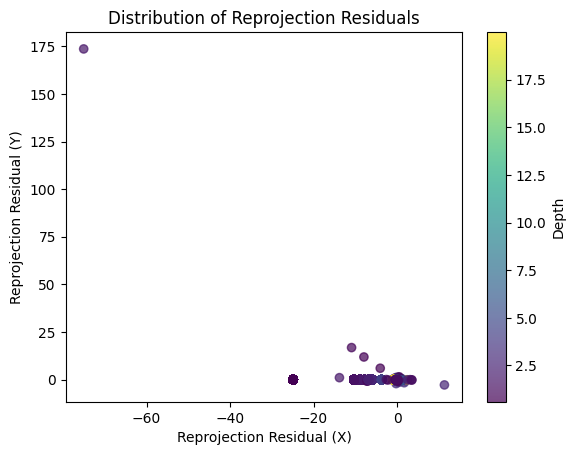

In [19]:
for batch in loader:
    img_left, img_right = batch["images"][:, 0].to(DEVICE), batch["images"][:, 1].to(DEVICE)
    K = torch.linalg.inv(batch["K_inv"])  # (3, 3) — same
    T = batch["T_lr"][0]  # (4, 4) — same

    #left_kps, right_kps = batch["left_kps"].to(DEVICE), batch["right_kps"].to(DEVICE)
    left_kps, right_kps, mask = SIFT(batch["images"], DEVICE, K)

    print(left_kps.shape, right_kps.shape)

    focal = K[0, 0]

    baseline = batch["baseline"][0].to(DEVICE)

    depth_left, depth_right = _get_depth(
        "gt", batch, left_kps, right_kps, focal, baseline,
        DEVICE, cfg.dataset.max_depth,
    )

    # right_reproj = reproject(left_kps, depth_left, K, T)
    # sigma_synth = 0.5
    # right_kps_synth = right_reproj + torch.randn_like(right_reproj) * sigma_synth
    # left_backproj = reproject(right_kps_synth, depth_left, K, torch.linalg.inv(T))

    # right_reproj_clean = reproject(left_kps, depth_left, K, T)             # exact
    # left_kps_synth = left_kps + torch.randn_like(left_kps) * 0.5
    # right_reproj_noised = reproject(left_kps_synth, depth_left, K, T)      # with noise
    # residuals = right_reproj_noised - right_reproj_clean

    left_reproj = reproject(right_kps, depth_right, K, torch.linalg.inv(T))
    residuals = left_kps - left_reproj

    # 2D scatter plot of residuals, colored by depth.
    plt.scatter(residuals[..., 0], residuals[..., 1], c=depth_left.flatten(), cmap='viridis', alpha=0.7)
    plt.xlabel("Reprojection Residual (X)")
    plt.ylabel("Reprojection Residual (Y)")
    plt.title("Distribution of Reprojection Residuals")
    plt.colorbar(label="Depth")
    plt.show()

    break

In [13]:
MAX_SAMPLES = 500   # ~500 * ~200 matches/pair ≈ 100k per config
BATCH_SIZE  = 8
repo_root   = "/Users/adam/Documents/MILA/projects/uncertainty_estimation"

all_residuals = {}  # key: "horizontal_5cm" -> (N, 2)

for orient in ORIENTATIONS:
    for b in BASELINES:
        stereo = f"{orient}_{b}cm"
        base    = OmegaConf.load(f"{repo_root}/configs/base.yaml")
        dataset = OmegaConf.load(f"{repo_root}/configs/dataset/sss.yaml")
        cfg     = OmegaConf.merge(base, {"dataset": dataset})
        cfg.dataset.stereo_config = stereo

        ds = SemiStaticSimStereoDataset(cfg.dataset, cfg.augmentation, "train", None)
        n_take = min(MAX_SAMPLES, len(ds))
        subset = torch.utils.data.Subset(ds, list(range(n_take)))
        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=0, collate_fn=stereo_collate)

        chunks = []
        with torch.no_grad():
            for batch in loader:
                K     = torch.linalg.inv(batch["K_inv"]).to(DEVICE)
                T_lr  = batch["T_lr"].to(DEVICE)
                T_rl  = torch.linalg.inv(T_lr)

                left_kps, right_kps, mask = SIFT(batch["images"], DEVICE, K)
                if left_kps.shape[1] == 0:
                    continue

                focal    = K[:, 0, 0]
                baseline = batch["baseline"].to(DEVICE)
                depth_l, depth_r = _get_depth(
                    "gt", batch, left_kps, right_kps, focal, baseline,
                    DEVICE, cfg.dataset.max_depth,
                )

                left_reproj = reproject(right_kps, depth_r, K, T_rl)
                H, W = batch["images"].shape[-2], batch["images"].shape[-1]
                valid = mask.bool() & _in_bounds(left_reproj, H, W)

                r = (left_kps - left_reproj)[valid].cpu().numpy()
                chunks.append(r)

        residuals = np.concatenate(chunks) if chunks else np.zeros((0, 2))
        all_residuals[stereo] = residuals
        print(f"{stereo:20s}  N={len(residuals):6d}")


horizontal_5cm        N=140755


KeyboardInterrupt: 

In [ ]:
from scipy.stats import chi2
import matplotlib.patches as mpatches
def plot_residuals(r, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(r[:, 0], r[:, 1], s=1, alpha=0.15)
    ax.set_aspect("equal"); ax.grid(alpha=0.2)
    ax.set_xlabel("rx (px)"); ax.set_ylabel("ry (px)")
    ax.set_title(title)
    plt.show()


horizontal_5cm        n=139180  σx=0.24  σy=0.13


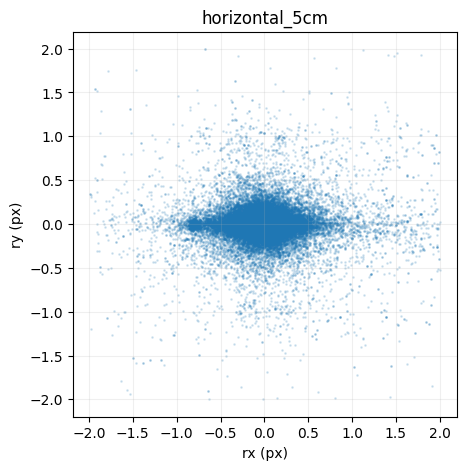

horizontal_10cm       n=103441  σx=0.27  σy=0.12


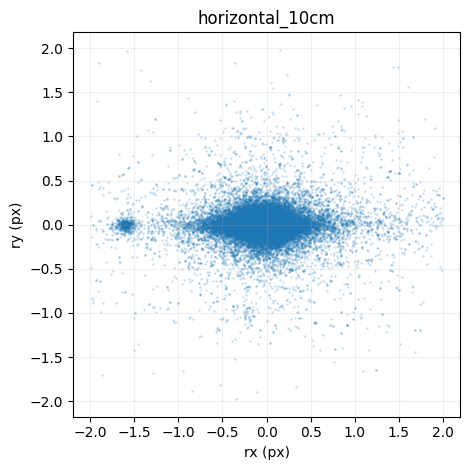

horizontal_20cm       n= 60582  σx=0.25  σy=0.12


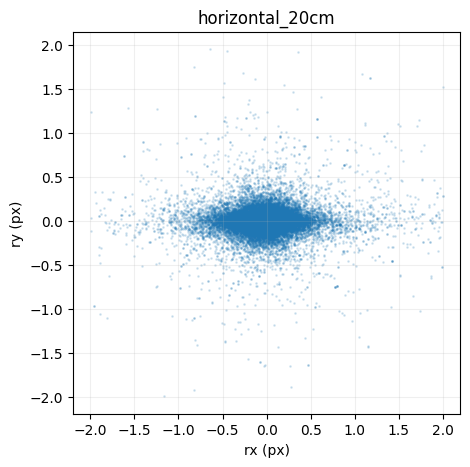

horizontal_50cm       n= 12851  σx=0.29  σy=0.12


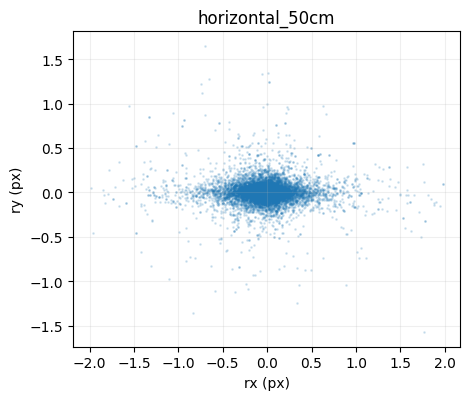

horizontal_100cm      n=   610  σx=0.50  σy=0.17


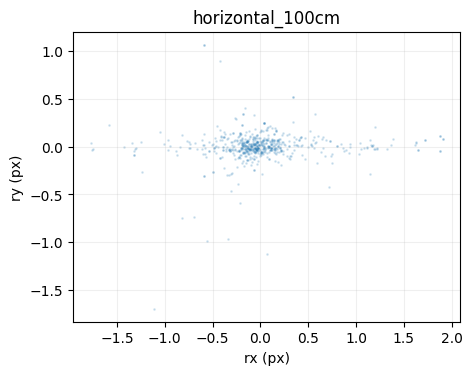

vertical_5cm          n=122811  σx=0.18  σy=0.21


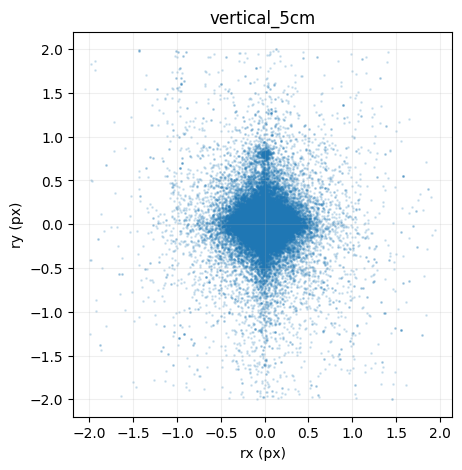

vertical_10cm         n= 89202  σx=0.19  σy=0.23


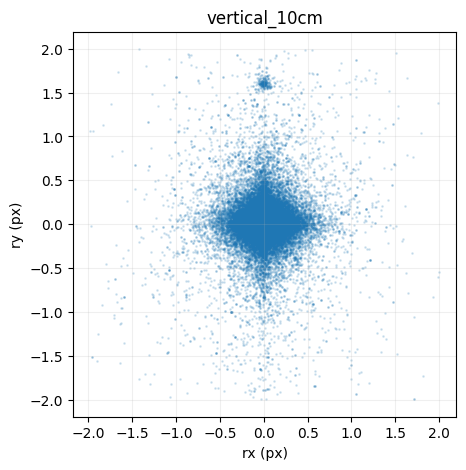

vertical_20cm         n= 48456  σx=0.21  σy=0.21


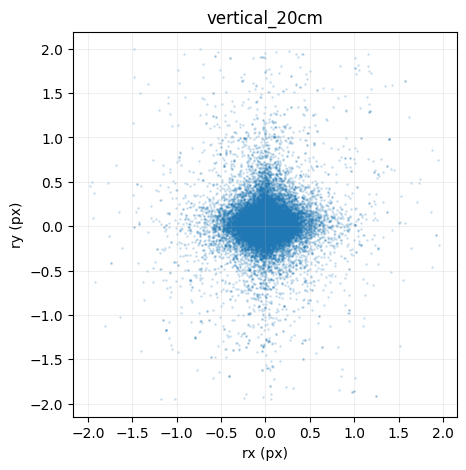

vertical_50cm         n=  6824  σx=0.26  σy=0.28


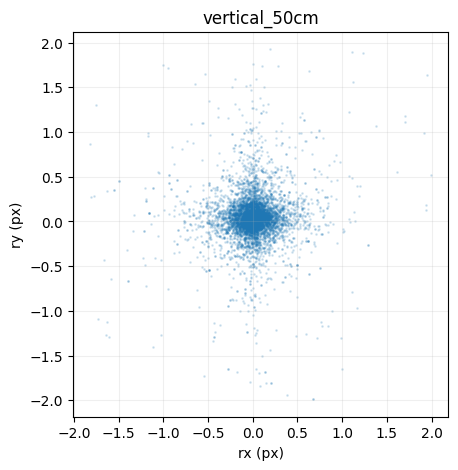

vertical_100cm        n=   192  σx=0.27  σy=0.42


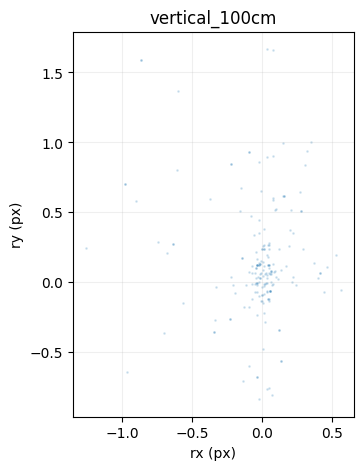

In [ ]:
for key, r in all_residuals.items():
    
    # limit range of residuals to ±5 px for better visualization
    r = r[np.abs(r[:, 0]) < 2]
    r = r[np.abs(r[:, 1]) < 2]
    print(f"{key:20s}  n={len(r):6d}  σx={r[:,0].std():.2f}  σy={r[:,1].std():.2f}")
    plot_residuals(r, title=key)

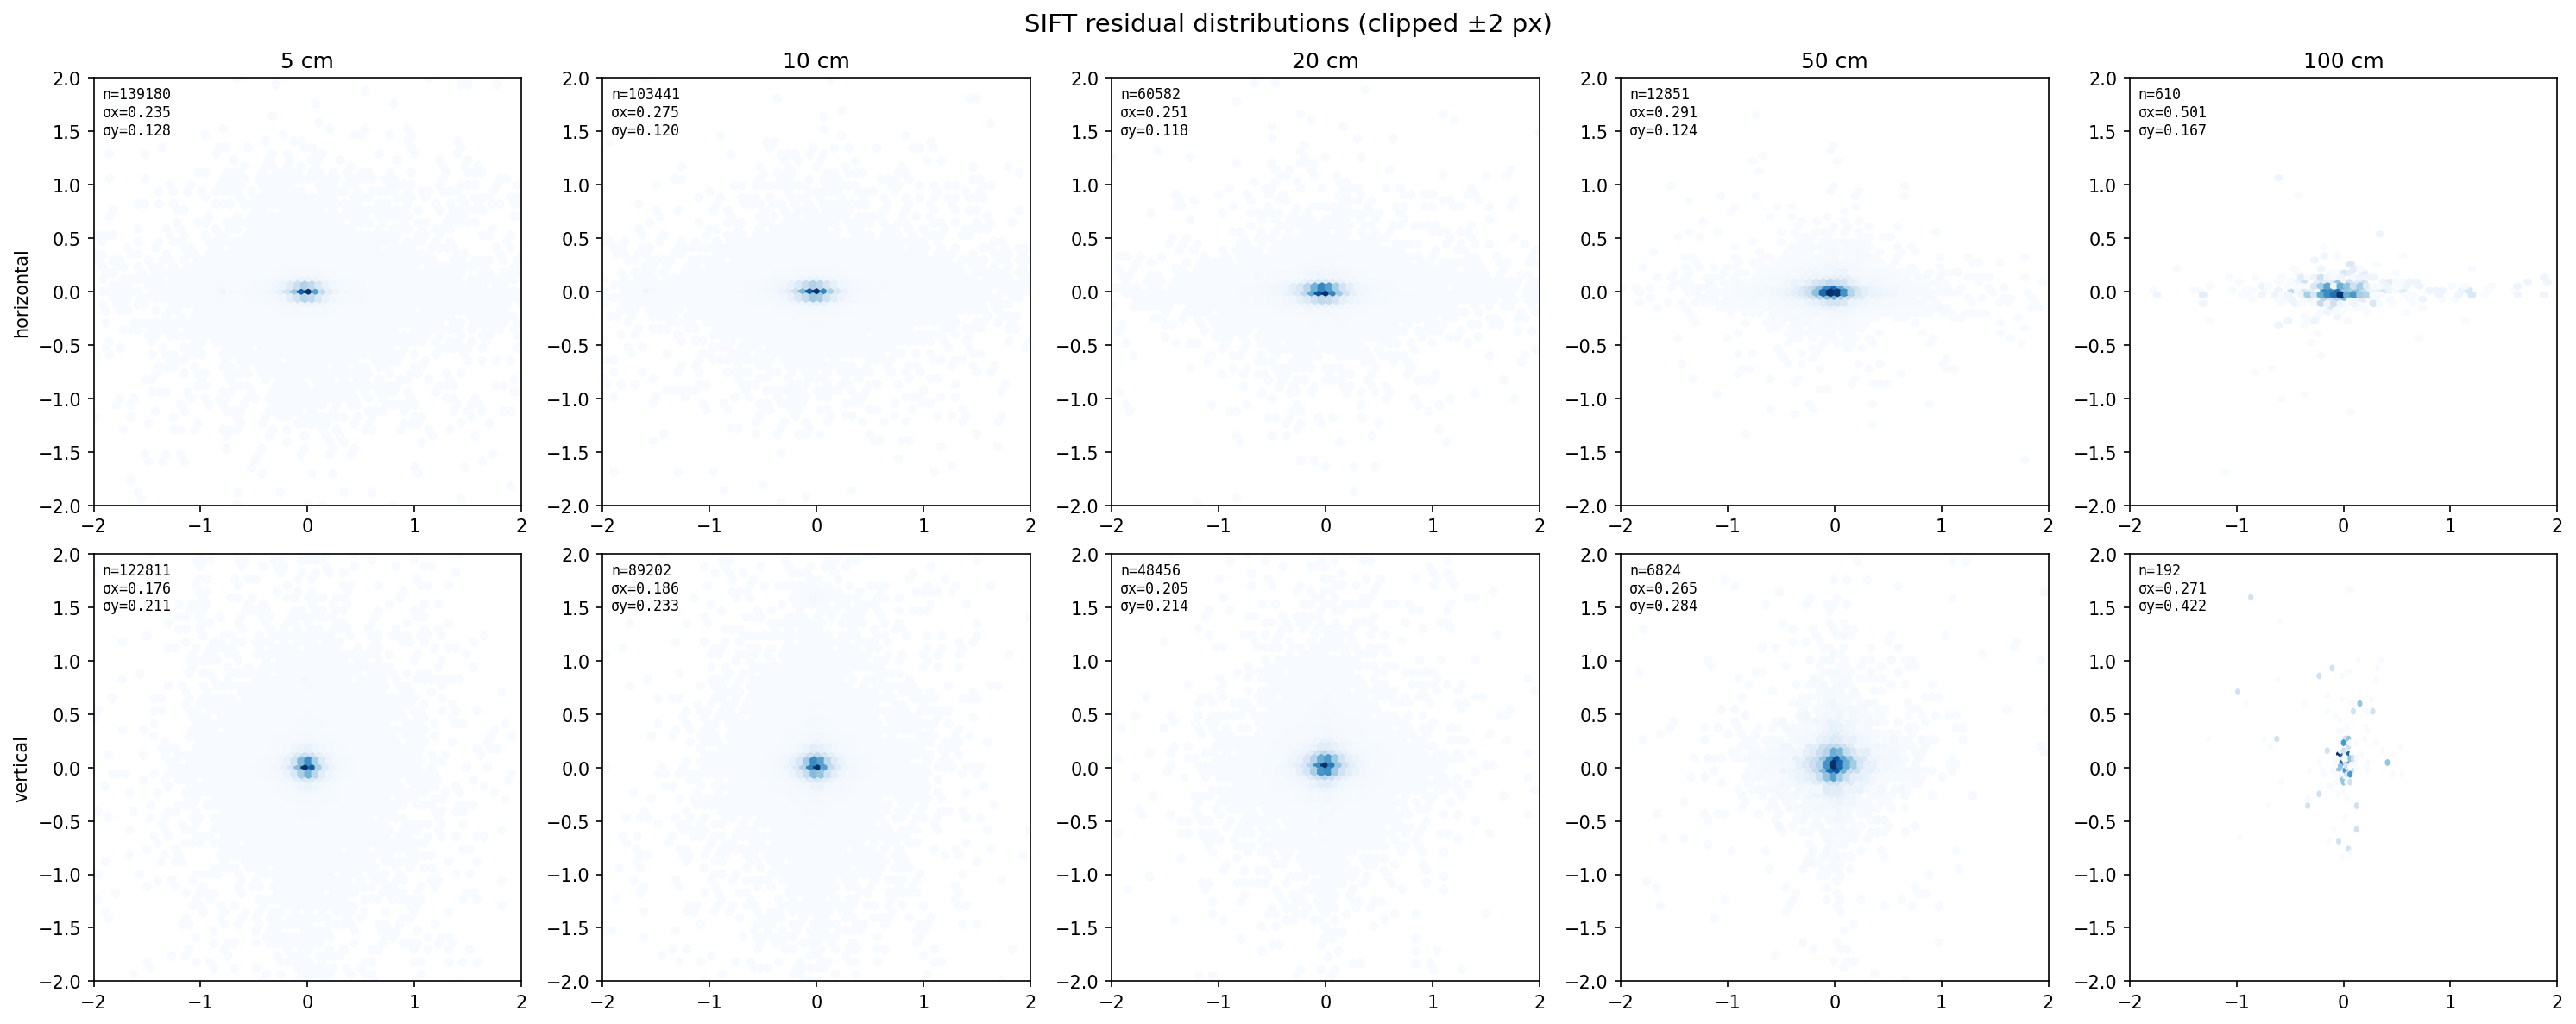

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), dpi=150)

for i, orient in enumerate(ORIENTATIONS):
    for j, b in enumerate(BASELINES):
        ax = axes[i, j]
        key = f"{orient}_{b}cm"
        r = all_residuals[key]
        r = r[(np.abs(r[:, 0]) < 2) & (np.abs(r[:, 1]) < 2)]

        ax.hexbin(r[:, 0], r[:, 1], gridsize=60, cmap="Blues", mincnt=1)
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
        ax.set_aspect("equal")
        ax.text(0.02, 0.98,
                f"n={len(r)}\nσx={r[:,0].std():.3f}\nσy={r[:,1].std():.3f}",
                transform=ax.transAxes, fontsize=8, va="top", family="monospace",
                bbox=dict(fc="white", alpha=0.8, pad=2, ec="none"))
        if i == 0: ax.set_title(f"{b} cm")
        if j == 0: ax.set_ylabel(orient)

fig.suptitle("SIFT residual distributions (clipped ±2 px)", fontsize=14)
fig.tight_layout()
fig.savefig(f"{repo_root}/outputs/eval/figs/sift_residuals_summary.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
def unproject(kps_px, depth, K):
    """kps_px: (B, N, 2), depth: (B, N), K: (B, 3, 3) -> (B, N, 3) in camera frame."""
    B, N, _ = kps_px.shape
    ones = torch.ones(B, N, 1, device=kps_px.device, dtype=kps_px.dtype)
    kps_h = torch.cat([kps_px, ones], dim=-1)                      # (B, N, 3)
    K_inv = torch.linalg.inv(K)                                     # (B, 3, 3)
    rays  = torch.einsum("bij,bnj->bni", K_inv, kps_h)              # (B, N, 3), z=1
    return rays * depth.unsqueeze(-1)                               # scale by Z

def transform_points(X, T):
    """X: (B, N, 3), T: (B, 4, 4) -> T @ X in homogeneous."""
    B, N, _ = X.shape
    ones = torch.ones(B, N, 1, device=X.device, dtype=X.dtype)
    Xh = torch.cat([X, ones], dim=-1)                               # (B, N, 4)
    return torch.einsum("bij,bnj->bni", T, Xh)[..., :3]

In [23]:
MAX_SAMPLES = 500   # ~500 * ~200 matches/pair ≈ 100k per config
BATCH_SIZE  = 8
repo_root   = "/Users/adam/Documents/MILA/projects/uncertainty_estimation"

all_residuals = {}  # key: "horizontal_5cm" -> (N, 2)

for orient in ORIENTATIONS:
    for b in BASELINES:
        stereo = f"{orient}_{b}cm"
        base    = OmegaConf.load(f"{repo_root}/configs/base.yaml")
        dataset = OmegaConf.load(f"{repo_root}/configs/dataset/sss.yaml")
        cfg     = OmegaConf.merge(base, {"dataset": dataset})
        cfg.dataset.stereo_config = stereo

        ds = SemiStaticSimStereoDataset(cfg.dataset, cfg.augmentation, "train", None)
        n_take = min(MAX_SAMPLES, len(ds))
        subset = torch.utils.data.Subset(ds, list(range(n_take)))
        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=0, collate_fn=stereo_collate)

        chunks = []
        with torch.no_grad():
            for batch in loader:
                K     = torch.linalg.inv(batch["K_inv"]).to(DEVICE)
                T_lr  = batch["T_lr"].to(DEVICE)
                T_rl  = torch.linalg.inv(T_lr)

                left_kps, right_kps, mask = SIFT(batch["images"], DEVICE, K)
                if left_kps.shape[1] == 0:
                    continue

                focal    = K[:, 0, 0]
                baseline = batch["baseline"].to(DEVICE)
                depth_l, depth_r = _get_depth(
                    "gt", batch, left_kps, right_kps, focal, baseline,
                    DEVICE, cfg.dataset.max_depth,
                )

                X_L = unproject(left_kps, depth_l, K)
                X_R = unproject(right_kps, depth_r, K)

                X_R_in_L = transform_points(X_R, T_rl)

                r_3D = X_L - X_R_in_L

                ray_L = X_L / X_L.norm(dim=-1, keepdim=True).clamp(min=1e-8)

                r_along = (r_3D * ray_L).sum(dim=-1, keepdim=True)  # (B, N)

                r_perp_vec = r_3D - r_along * ray_L
                r_perp_norm = r_perp_vec.norm(dim=-1, keepdim=True)  # (B, N)

                packed = torch.cat([r_3D, r_along, r_perp_norm, depth_l.unsqueeze(-1)], dim=-1)
                depth_ok = (depth_l > 0.1) & (depth_l < cfg.dataset.max_depth - 1e-3) & \
                        (depth_r > 0.1) & (depth_r < cfg.dataset.max_depth - 1e-3)
                # Structural: clean 2D reprojection both directions (the real filter)
                r2d_right = (right_kps - reproject(left_kps,  depth_l, K, T_lr)).norm(dim=-1)
                r2d_left  = (left_kps  - reproject(right_kps, depth_r, K, T_rl)).norm(dim=-1)
                clean_2d  = (r2d_right < 2.0) & (r2d_left < 2.0)
                valid = mask.bool() & _in_bounds(left_kps, *batch["images"].shape[-2:]) & depth_ok & clean_2d
                r_out = packed[valid].cpu().numpy()
                chunks.append(r_out)

        residuals = np.concatenate(chunks) if chunks else np.zeros((0, 2))
        all_residuals[stereo] = residuals
        print(f"{stereo:20s}  N={len(residuals):6d}")


horizontal_5cm        N=139070
horizontal_10cm       N=103392
horizontal_20cm       N= 60552
horizontal_50cm       N= 12848
horizontal_100cm      N=   608
vertical_5cm          N=122695
vertical_10cm         N= 89119
vertical_20cm         N= 48407
vertical_50cm         N=  6798
vertical_100cm        N=   191


In [24]:
for key, r in all_residuals.items():
    rx, ry, rz, ralong, rperp, Z = r.T
    print(f"{key:20s}  n={len(r):6d}  "
          f"σx={rx.std():.3f}m  σy={ry.std():.3f}m  σz={rz.std():.3f}m  "
          f"σ_along={ralong.std():.3f}m  σ_perp={rperp.std():.3f}m  "
          f"Z_median={np.median(Z):.2f}m")

horizontal_5cm        n=139070  σx=0.005m  σy=0.002m  σz=0.004m  σ_along=0.005m  σ_perp=0.004m  Z_median=1.84m
horizontal_10cm       n=103392  σx=0.009m  σy=0.001m  σz=0.003m  σ_along=0.005m  σ_perp=0.008m  Z_median=1.94m
horizontal_20cm       n= 60552  σx=0.002m  σy=0.001m  σz=0.002m  σ_along=0.002m  σ_perp=0.002m  Z_median=2.07m
horizontal_50cm       n= 12848  σx=0.003m  σy=0.001m  σz=0.002m  σ_along=0.002m  σ_perp=0.002m  Z_median=2.50m
horizontal_100cm      n=   608  σx=0.006m  σy=0.002m  σz=0.004m  σ_along=0.004m  σ_perp=0.005m  Z_median=2.92m
vertical_5cm          n=122695  σx=0.023m  σy=0.026m  σz=0.041m  σ_along=0.053m  σ_perp=0.004m  Z_median=1.78m
vertical_10cm         n= 89119  σx=0.002m  σy=0.007m  σz=0.005m  σ_along=0.005m  σ_perp=0.006m  Z_median=1.89m
vertical_20cm         n= 48407  σx=0.002m  σy=0.002m  σz=0.002m  σ_along=0.003m  σ_perp=0.002m  Z_median=2.09m
vertical_50cm         n=  6798  σx=0.002m  σy=0.002m  σz=0.002m  σ_along=0.003m  σ_perp=0.002m  Z_median=2.57m
v

/var/folders/br/cmzzcsb57_98q6bdzbmph71r0000gn/T/ipykernel_11696/1209912495.py:21: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/Users/adam/Documents/MILA/projects/uncertainty_estimation/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


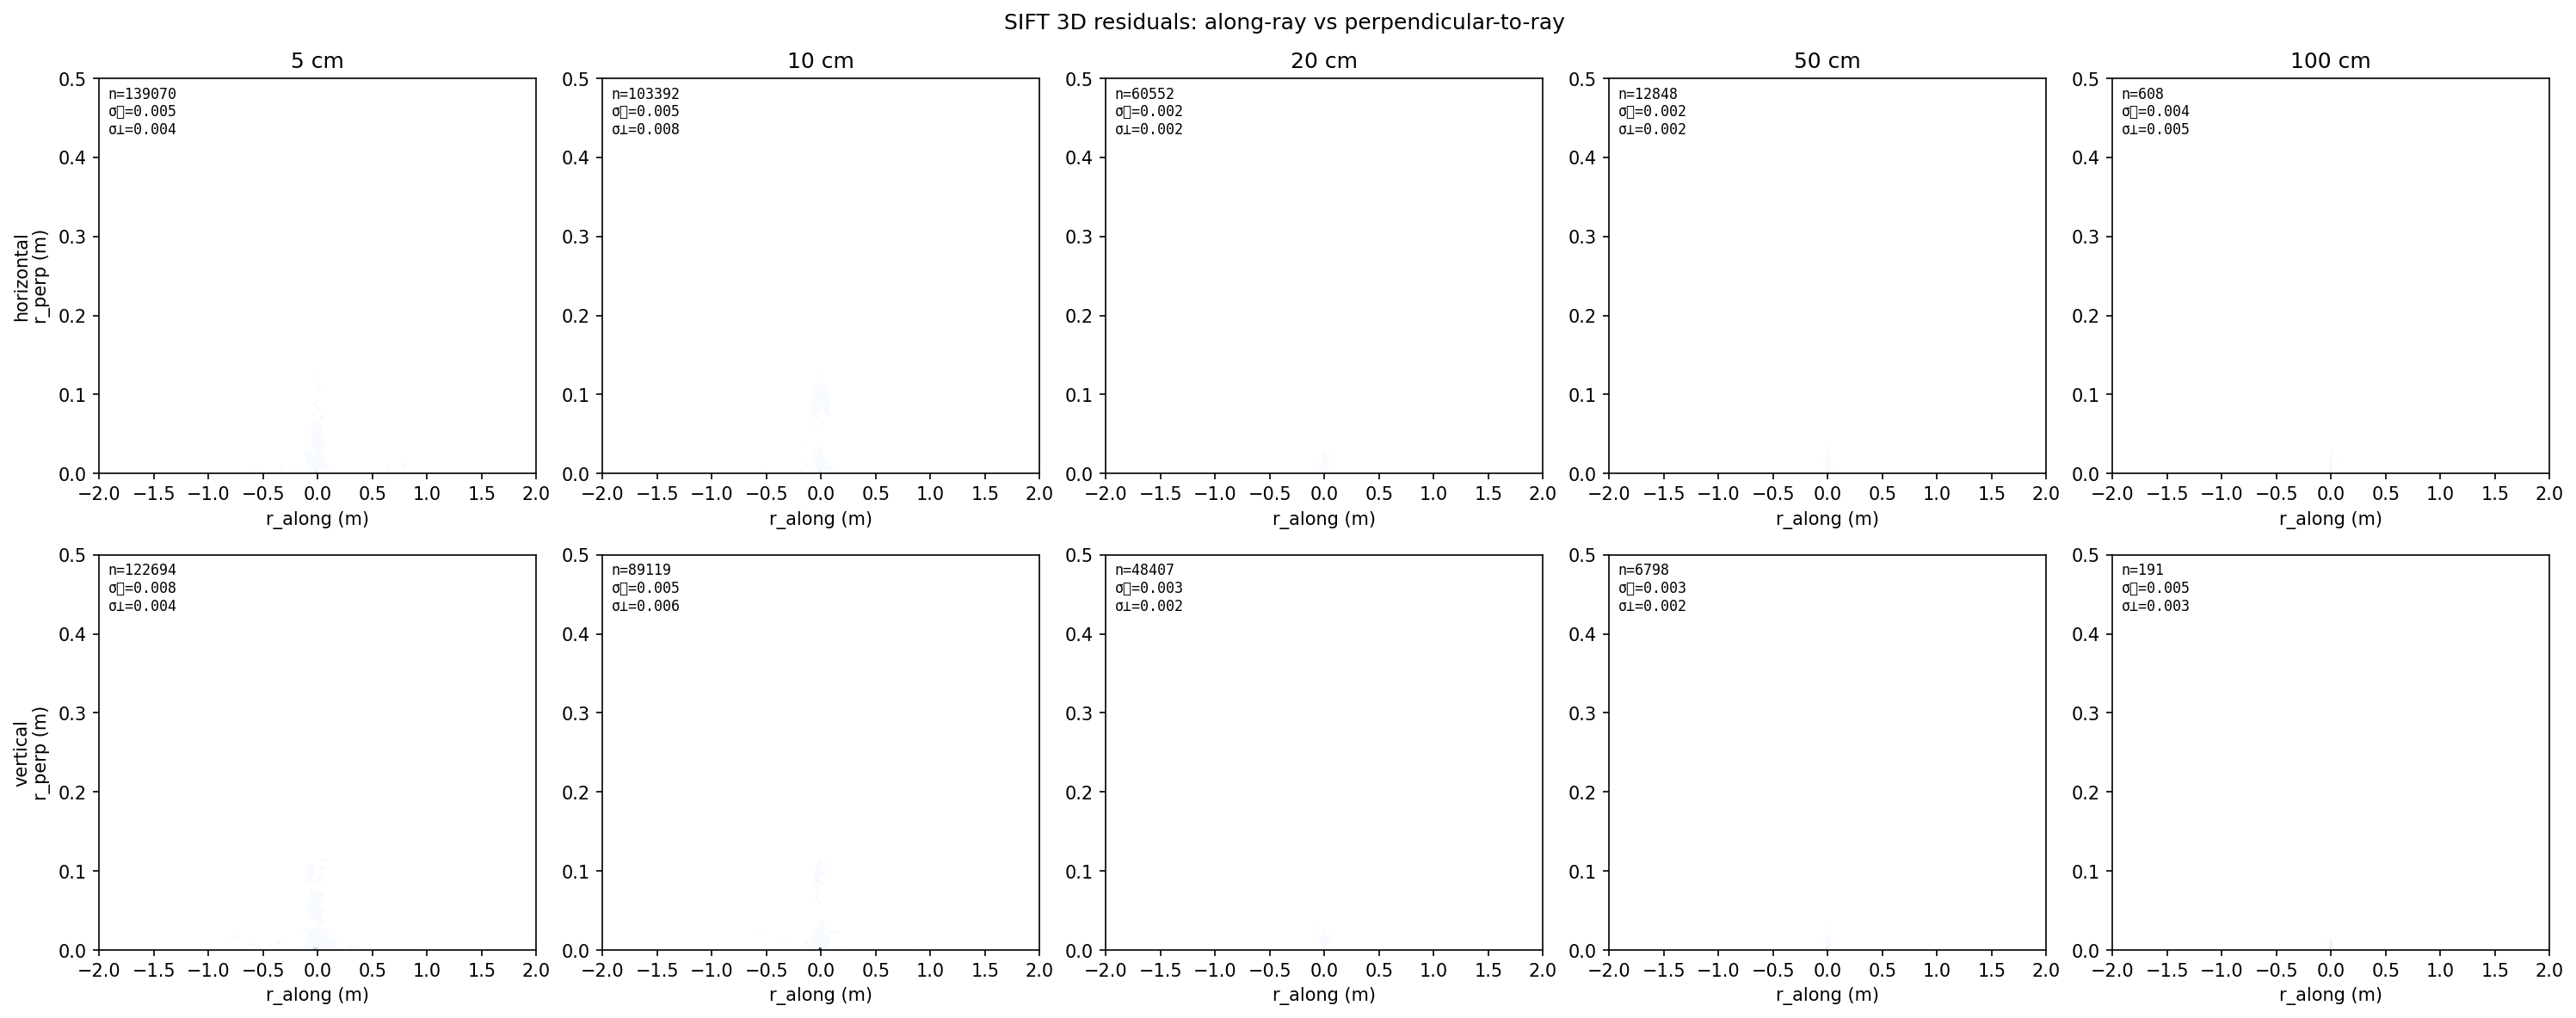

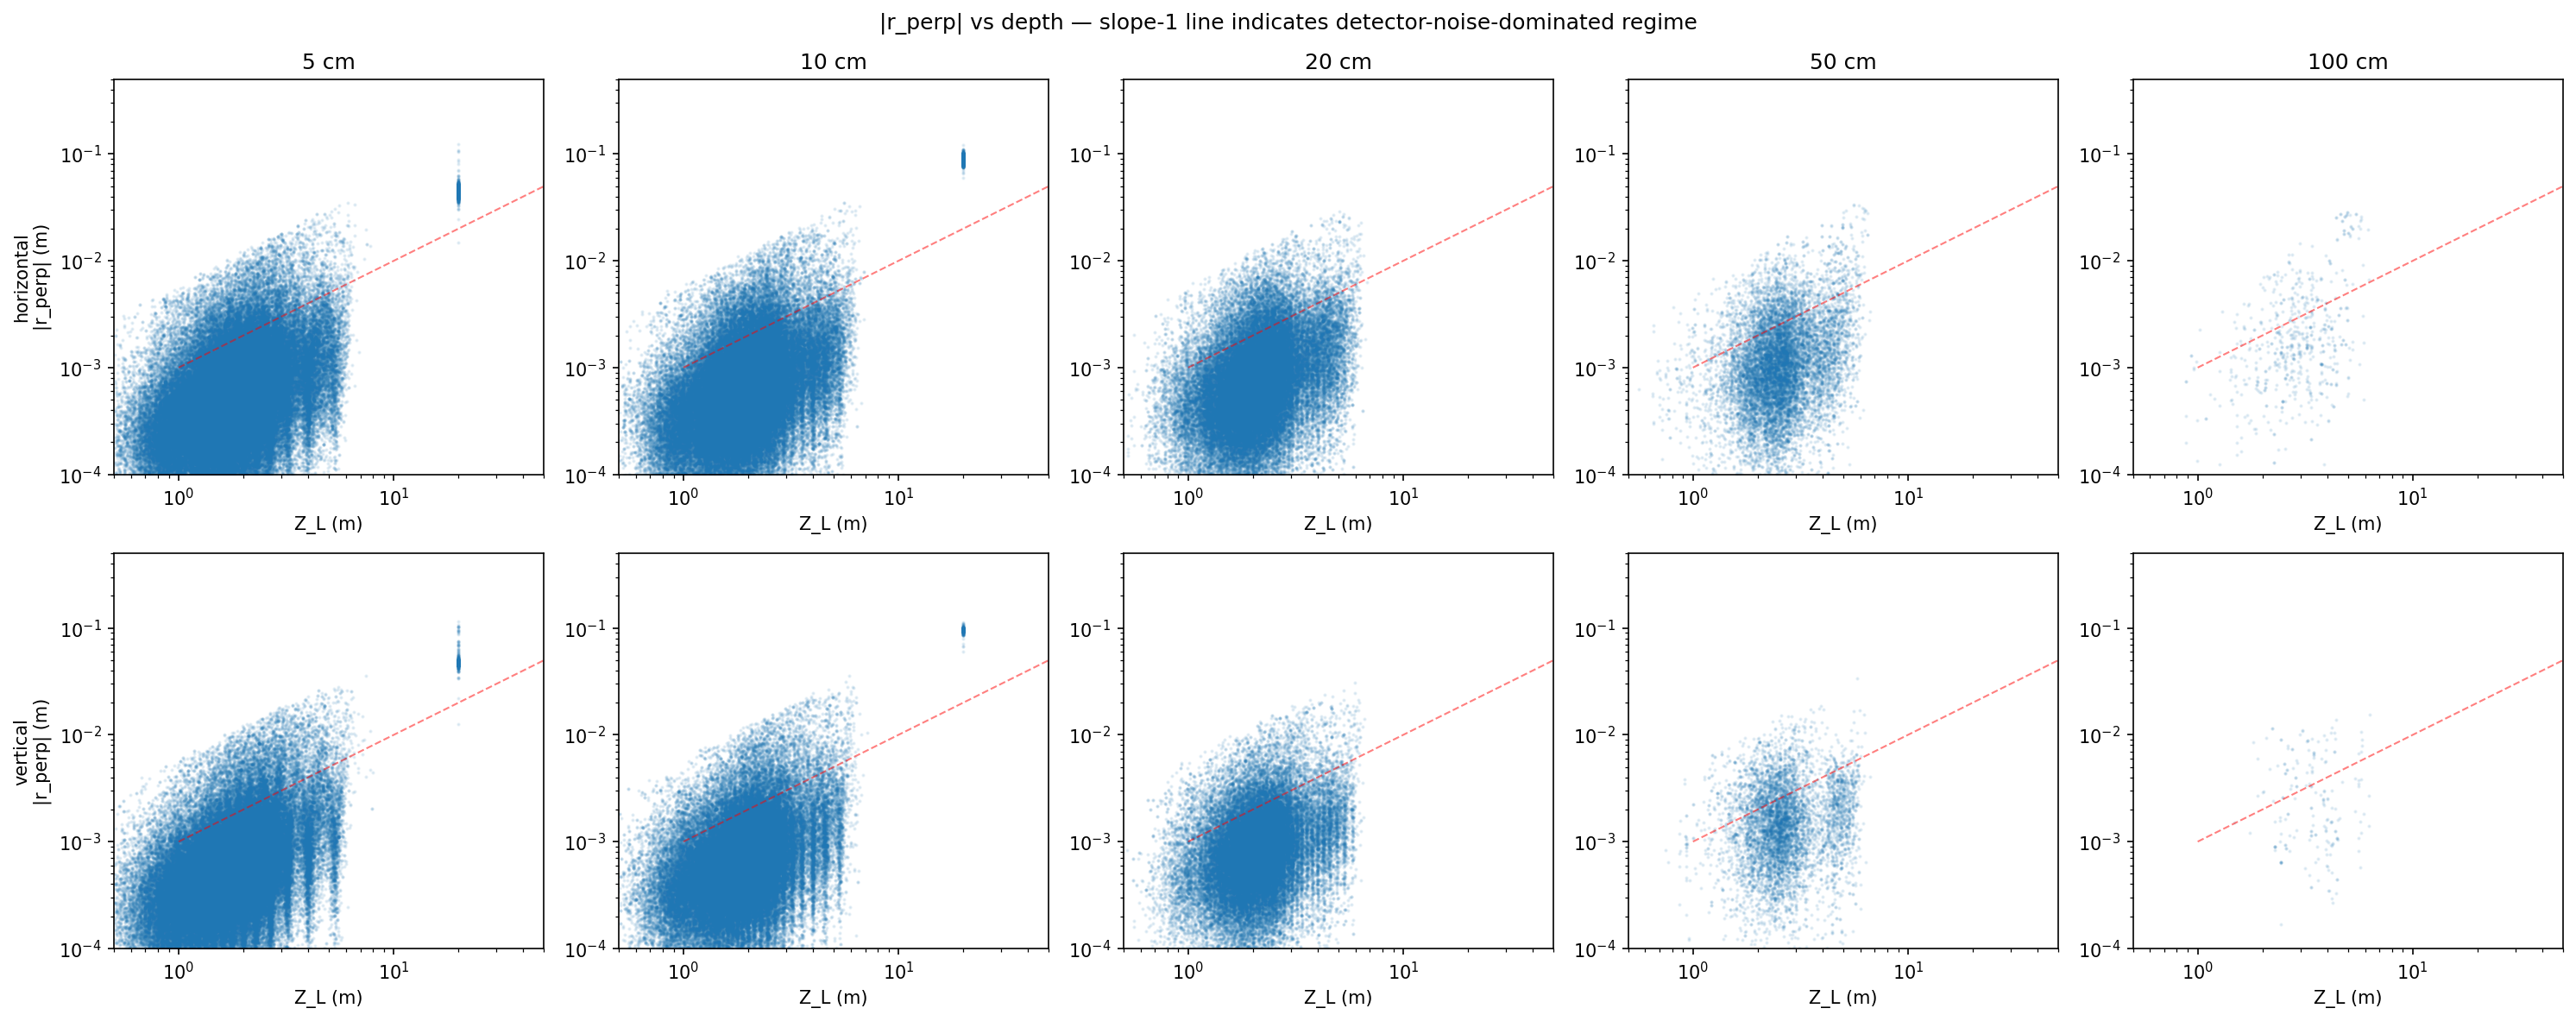

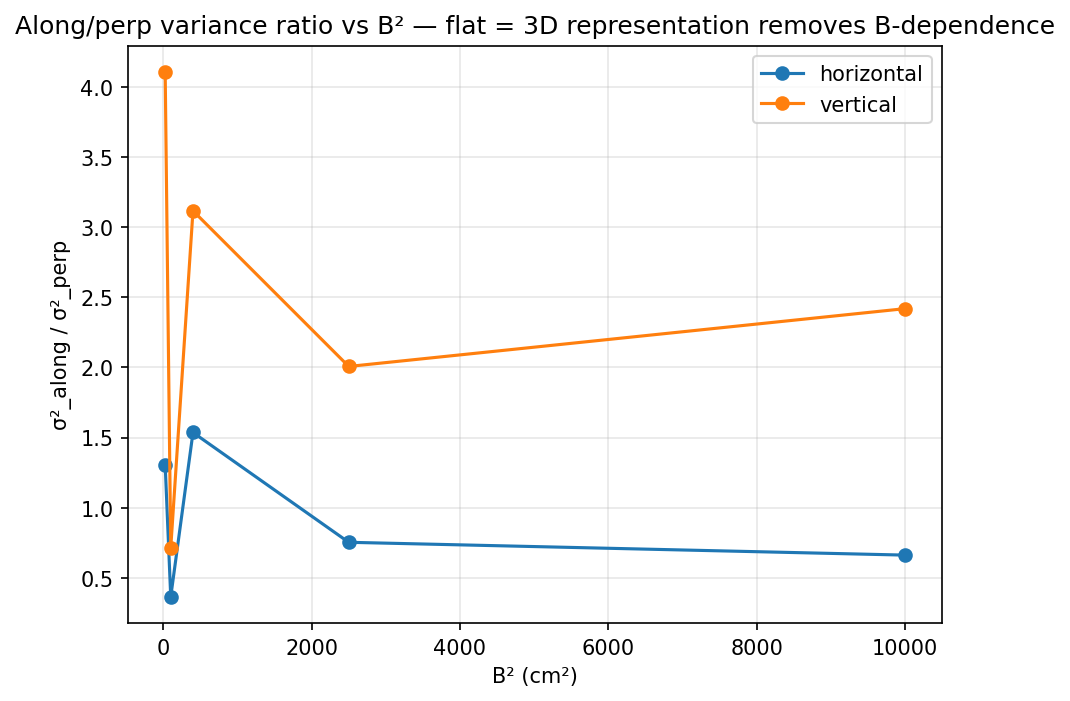

In [25]:
# Plot 1: scatter of along-ray vs perp-norm, colored by log-depth
fig, axes = plt.subplots(2, 5, figsize=(20, 8), dpi=150)
for i, orient in enumerate(ORIENTATIONS):
    for j, b in enumerate(BASELINES):
        ax = axes[i, j]
        key = f"{orient}_{b}cm"
        r = all_residuals[key]
        ralong, rperp, Z = r[:, 3], r[:, 4], r[:, 5]
        # Clip to reasonable range for visualization (in meters)
        m = (np.abs(ralong) < 2.0) & (rperp < 0.5)
        ax.hexbin(ralong[m], rperp[m], gridsize=60, cmap="Blues", mincnt=1)
        ax.set_xlim(-2, 2); ax.set_ylim(0, 0.5)
        ax.text(0.02, 0.98,
                f"n={m.sum()}\nσ∥={ralong[m].std():.3f}\nσ⊥={rperp[m].std():.3f}",
                transform=ax.transAxes, fontsize=8, va="top", family="monospace",
                bbox=dict(fc="white", alpha=0.8, pad=2, ec="none"))
        if i == 0: ax.set_title(f"{b} cm")
        if j == 0: ax.set_ylabel(f"{orient}\nr_perp (m)")
        ax.set_xlabel("r_along (m)")
fig.suptitle("SIFT 3D residuals: along-ray vs perpendicular-to-ray")
fig.tight_layout()
plt.show()

# Plot 2: log-log of |r_perp| vs Z_L — should be linear with slope 1 if detector-dominated
fig, axes = plt.subplots(2, 5, figsize=(20, 8), dpi=150)
for i, orient in enumerate(ORIENTATIONS):
    for j, b in enumerate(BASELINES):
        ax = axes[i, j]
        key = f"{orient}_{b}cm"
        r = all_residuals[key]
        rperp, Z = r[:, 4], r[:, 5]
        m = (rperp > 1e-5) & (rperp < 0.5) & (Z > 0.5) & (Z < 50)
        ax.scatter(Z[m], rperp[m], s=1, alpha=0.1)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(0.5, 50); ax.set_ylim(1e-4, 0.5)
        # Overlay slope-1 reference
        zr = np.array([1, 50])
        ax.plot(zr, 1e-3 * zr, "r--", alpha=0.5, lw=1, label="slope 1")
        if i == 0: ax.set_title(f"{b} cm")
        if j == 0: ax.set_ylabel(f"{orient}\n|r_perp| (m)")
        ax.set_xlabel("Z_L (m)")
fig.suptitle("|r_perp| vs depth — slope-1 line indicates detector-noise-dominated regime")
fig.tight_layout()
plt.show()

# Plot 3: σ_along^2 / σ_perp^2 vs B^2 — should be flat in 3D (depth noise no longer B-dependent)
# (In pixel space this ratio scales as B^2; in 3D it shouldn't.)
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
for orient in ORIENTATIONS:
    ratios, Bs = [], []
    for b in BASELINES:
        r = all_residuals[f"{orient}_{b}cm"]
        ralong, rperp = r[:, 3], r[:, 4]
        m = (np.abs(ralong) < 2.0) & (rperp < 0.5)
        ratios.append(ralong[m].var() / max(rperp[m].var(), 1e-12))
        Bs.append(b)
    ax.plot(np.array(Bs)**2, ratios, "o-", label=orient)
ax.set_xlabel("B² (cm²)"); ax.set_ylabel("σ²_along / σ²_perp")
ax.set_title("Along/perp variance ratio vs B² — flat = 3D representation removes B-dependence")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [26]:
from torch import Tensor

def _lookup_depth(depth_map: Tensor, kps: Tensor) -> Tensor:
    """Sample a dense depth map at keypoint locations (nearest-neighbour).

    Args:
        depth_map: (B, H, W) depth in metres.
        kps:       (B, P, 2) keypoints in pixel coords (x=col, y=row).

    Returns:
        (B, P) depth values at each keypoint.
    """
    B, H, W = depth_map.shape
    col = kps[..., 0].round().long().clamp(0, W - 1) # (B, P)
    row = kps[..., 1].round().long().clamp(0, H - 1) # (B, P)
    b_idx = torch.arange(B, device=kps.device).unsqueeze(1).expand_as(col) # (B, P)
    return depth_map[b_idx, row, col] # now we can have depth_map[b_idx[i, j], row[i, j], col[i, j]] for each keypoint

def simulate(
    images, depth_maps, K, T_lr,
    sigma_det_px: float,
    sigma_Z_m: float,
    n_kps: int = 500,
):
    device = depth_maps.device
    dtype = depth_maps.dtype
    B = images.shape[0]
    H, W = images.shape[-2:]
    T_rl = torch.linalg.inv(T_lr)

    # 1. Sample uniform random left-image locations
    u_L = torch.rand(B, n_kps, 2, device=device, dtype=dtype) * \
          torch.tensor([W - 1, H - 1], device=device, dtype=dtype)

    # 2. Look up GT depth at left keypoints
    Z_L = _lookup_depth(depth_maps[:, 0], u_L)
    valid = (Z_L > 0.5) & (Z_L < 50.0)

    # 3. GT right correspondence by projection
    u_R_gt = reproject(u_L, Z_L, K, T_lr)

    in_bounds_R = (u_R_gt[..., 0] >= 0) & (u_R_gt[..., 0] < W) & \
                  (u_R_gt[..., 1] >= 0) & (u_R_gt[..., 1] < H)
    valid = valid & in_bounds_R

    Z_R_gt = _lookup_depth(depth_maps[:, 1], u_R_gt)
    valid = valid & (Z_R_gt > 0.5) & (Z_R_gt < 50.0)

    # 4. Inject independent noise
    eps1 = sigma_det_px * torch.randn_like(u_L)
    eps2 = sigma_det_px * torch.randn_like(u_R_gt)
    dZ_L = sigma_Z_m * torch.randn_like(Z_L)
    dZ_R = sigma_Z_m * torch.randn_like(Z_R_gt)

    u_L_noisy = u_L + eps1
    u_R_noisy = u_R_gt + eps2
    Z_L_noisy = Z_L + dZ_L
    Z_R_noisy = Z_R_gt + dZ_R

    # 5. Pixel residual as seen by the loss
    u_R_reproj = reproject(u_L_noisy, Z_L_noisy, K, T_lr)
    r_2d = u_R_noisy - u_R_reproj

    # 6. 3D residual in left frame
    X_L_recon = unproject(u_L_noisy, Z_L_noisy, K)
    X_R_recon = unproject(u_R_noisy, Z_R_noisy, K)
    X_R_in_L = transform_points(X_R_recon, T_rl)
    r_3d = X_L_recon - X_R_in_L

    return r_2d[valid], r_3d[valid], Z_L[valid], u_L[valid]

In [30]:
NOISE_CONDITIONS = {
    # "detector_only":   dict(sigma_det_px=0.5, sigma_Z_m=0.0),
    # "depth_only":      dict(sigma_det_px=0.0, sigma_Z_m=0.1),
    "both":            dict(sigma_det_px=0.5, sigma_Z_m=0.1),
    # "zero_sanity":     dict(sigma_det_px=0.0, sigma_Z_m=0.0),  # run this first
}

N_KPS       = 500
MAX_SAMPLES = 500
BATCH_SIZE  = 8
repo_root   = "/Users/adam/Documents/MILA/projects/uncertainty_estimation"

# Nested dict: condition -> stereo -> (r_2d, r_3d, Z_L, u_L) as numpy arrays
all_results = {cond: {} for cond in NOISE_CONDITIONS}

for orient in ORIENTATIONS:
    for b in BASELINES:
        stereo = f"{orient}_{b}cm"
        base    = OmegaConf.load(f"{repo_root}/configs/base.yaml")
        dataset = OmegaConf.load(f"{repo_root}/configs/dataset/sss.yaml")
        cfg     = OmegaConf.merge(base, {"dataset": dataset})
        cfg.dataset.stereo_config = stereo

        # matching_cfg=None so __getitem__ doesn't run ORB — we don't need matches
        ds = SemiStaticSimStereoDataset(cfg.dataset, cfg.augmentation, "train", None)
        n_take = min(MAX_SAMPLES, len(ds))
        subset = torch.utils.data.Subset(ds, list(range(n_take)))
        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=0, collate_fn=stereo_collate)

        # Accumulate per-condition chunks across batches
        chunks = {cond: {"r_2d": [], "r_3d": [], "Z_L": [], "u_L": []} 
                  for cond in NOISE_CONDITIONS}

        with torch.no_grad():
            for batch in loader:
                images     = batch["images"].to(DEVICE)       # (B, 2, C, H, W)
                K          = torch.linalg.inv(batch["K_inv"]).to(DEVICE)
                T_lr       = batch["T_lr"].to(DEVICE)
                depth_maps = torch.stack([
                    batch["depth_left"].to(DEVICE),
                    batch["depth_right"].to(DEVICE),
                ], dim=1)                                      # (B, 2, H, W)

                for cond_name, noise_kwargs in NOISE_CONDITIONS.items():
                    r_2d, r_3d, Z_L, u_L = simulate(
                        images, depth_maps, K, T_lr,
                        n_kps=N_KPS, **noise_kwargs,
                    )
                    chunks[cond_name]["r_2d"].append(r_2d.cpu().numpy())
                    chunks[cond_name]["r_3d"].append(r_3d.cpu().numpy())
                    chunks[cond_name]["Z_L"].append(Z_L.cpu().numpy())
                    chunks[cond_name]["u_L"].append(u_L.cpu().numpy())

        for cond_name in NOISE_CONDITIONS:
            all_results[cond_name][stereo] = {
                k: np.concatenate(v) for k, v in chunks[cond_name].items()
            }
            r_2d = all_results[cond_name][stereo]["r_2d"]
            print(f"{cond_name:15s}  {stereo:20s}  N={len(r_2d):6d}  "
                  f"σx={r_2d[:,0].std():.3f}  σy={r_2d[:,1].std():.3f}")

both             horizontal_5cm        N=237422  σx=1.719  σy=0.706
both             horizontal_10cm       N=232675  σx=3.173  σy=0.707
both             horizontal_20cm       N=222925  σx=5.588  σy=0.707
both             horizontal_50cm       N=192684  σx=11.852  σy=0.707
both             horizontal_100cm      N=157874  σx=19.059  σy=0.706
both             vertical_5cm          N=237136  σx=0.709  σy=1.734
both             vertical_10cm         N=231949  σx=0.708  σy=3.268
both             vertical_20cm         N=221844  σx=0.708  σy=6.303
both             vertical_50cm         N=193919  σx=0.707  σy=14.617
both             vertical_100cm        N=151864  σx=0.707  σy=22.792
